<a href="https://colab.research.google.com/github/ishmarai/free_cash_flow_prediction/blob/main/Operatingcashflow_p.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Finance/master_ml_dataset.csv")
print(df.shape)
# print(df.info)
print(df.columns)


(477, 44)
Index(['Ticker', 'Year', 'Year_Int', 'COD_Year', 'Years_Since_COD',
       'Pre_Post_COD', 'Revenue', 'EBIT', 'PAT', 'CapEx', 'Change_in_WC',
       'Depreciation_Expense', 'Interest_Expense', 'Tax_Rate',
       'Working_Capital', 'FCF', 'EBIT_Margin', 'Net_Profit_Margin',
       'Debt_Ratio', 'Current_Ratio', 'ROA', 'ROE', 'Asset_Turnover',
       'Interest_Burden', 'Revenue_Growth', 'EBIT_Growth', 'Revenue_Lag1',
       'FCF_Lag1', 'Revenue_Growth_Lag1', 'Rolling3_Avg_Rev_Growth',
       'Rolling3_Avg_Ebit_Margin', 'Installed_Capacity_MW',
       'License_Issue_Year', 'License_Term_Years', 'PPA_Tariff_Wet',
       'PPA_Tariff_Dry', 'PLF', 'GDP_Growth', 'Inflation', 'Interest_Rate',
       'Total_IPP_Generation_GWh', 'Power_Import_From_India_GWh',
       'National_Peak_Demand_MW', 'OperatingCashFlow_Proxy'],
      dtype='object')


null value, visualization,

In [ ]:
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


,0
Ticker,0
Year,0
Year_Int,0
COD_Year,14
Years_Since_COD,14
Pre_Post_COD,0
Revenue,0
EBIT,0
PAT,0
CapEx,0


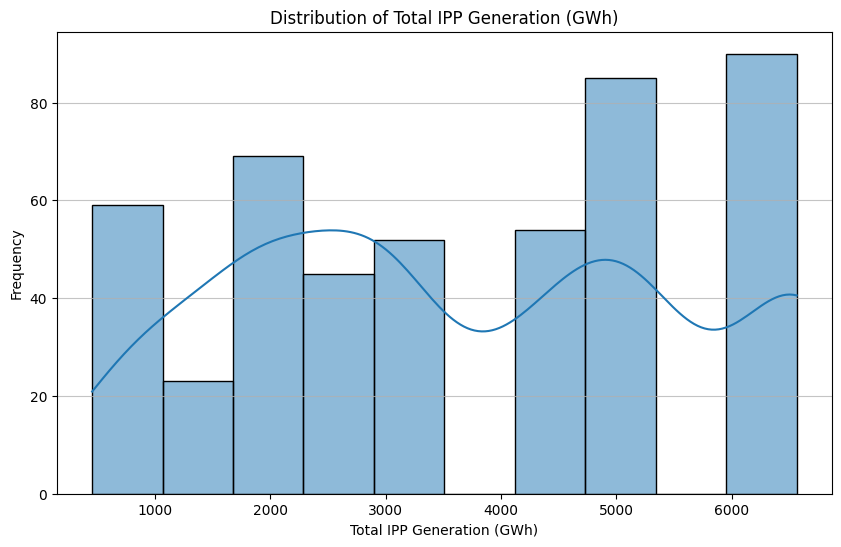

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Total_IPP_Generation_GWh'].dropna(), kde=True)
plt.title('Distribution of Total IPP Generation (GWh)')
plt.xlabel('Total IPP Generation (GWh)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

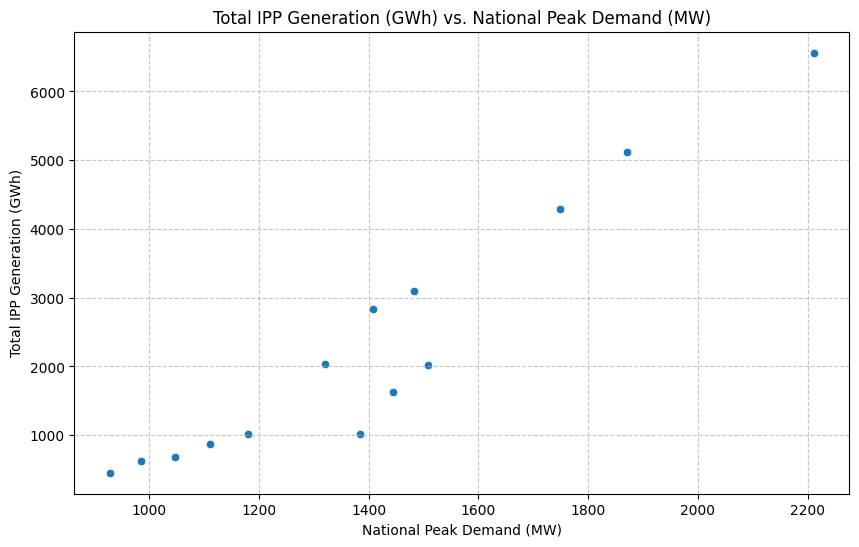

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='National_Peak_Demand_MW', y='Total_IPP_Generation_GWh', data=df)
plt.title('Total IPP Generation (GWh) vs. National Peak Demand (MW)')
plt.xlabel('National Peak Demand (MW)')
plt.ylabel('Total IPP Generation (GWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
correlation = df['Total_IPP_Generation_GWh'].corr(df['Interest_Rate'])
print(f"Correlation between 'Total_IPP_Generation_GWh' and 'Interest_Rate': {correlation}")

Correlation between 'Total_IPP_Generation_GWh' and 'Interest_Rate': -0.013572982268332324


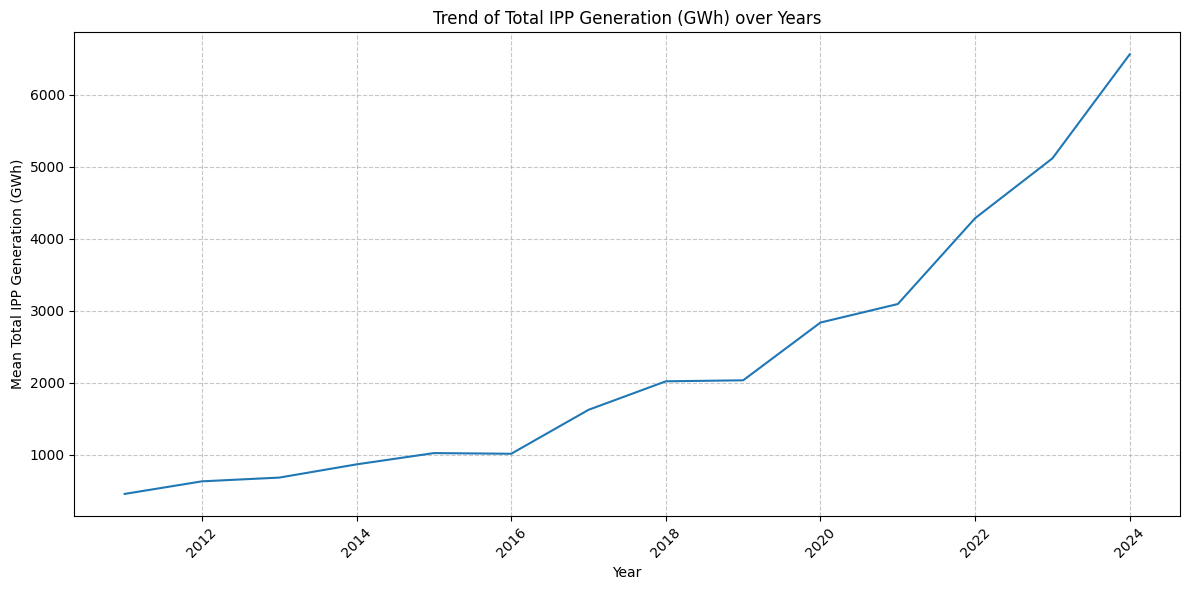

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Year_Int' is treated as a numeric column
df['Year_Int'] = pd.to_numeric(df['Year_Int'], errors='coerce')

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year_Int', y='Total_IPP_Generation_GWh', data=df, estimator='mean', errorbar=None)
plt.title('Trend of Total IPP Generation (GWh) over Years')
plt.xlabel('Year')
plt.ylabel('Mean Total IPP Generation (GWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

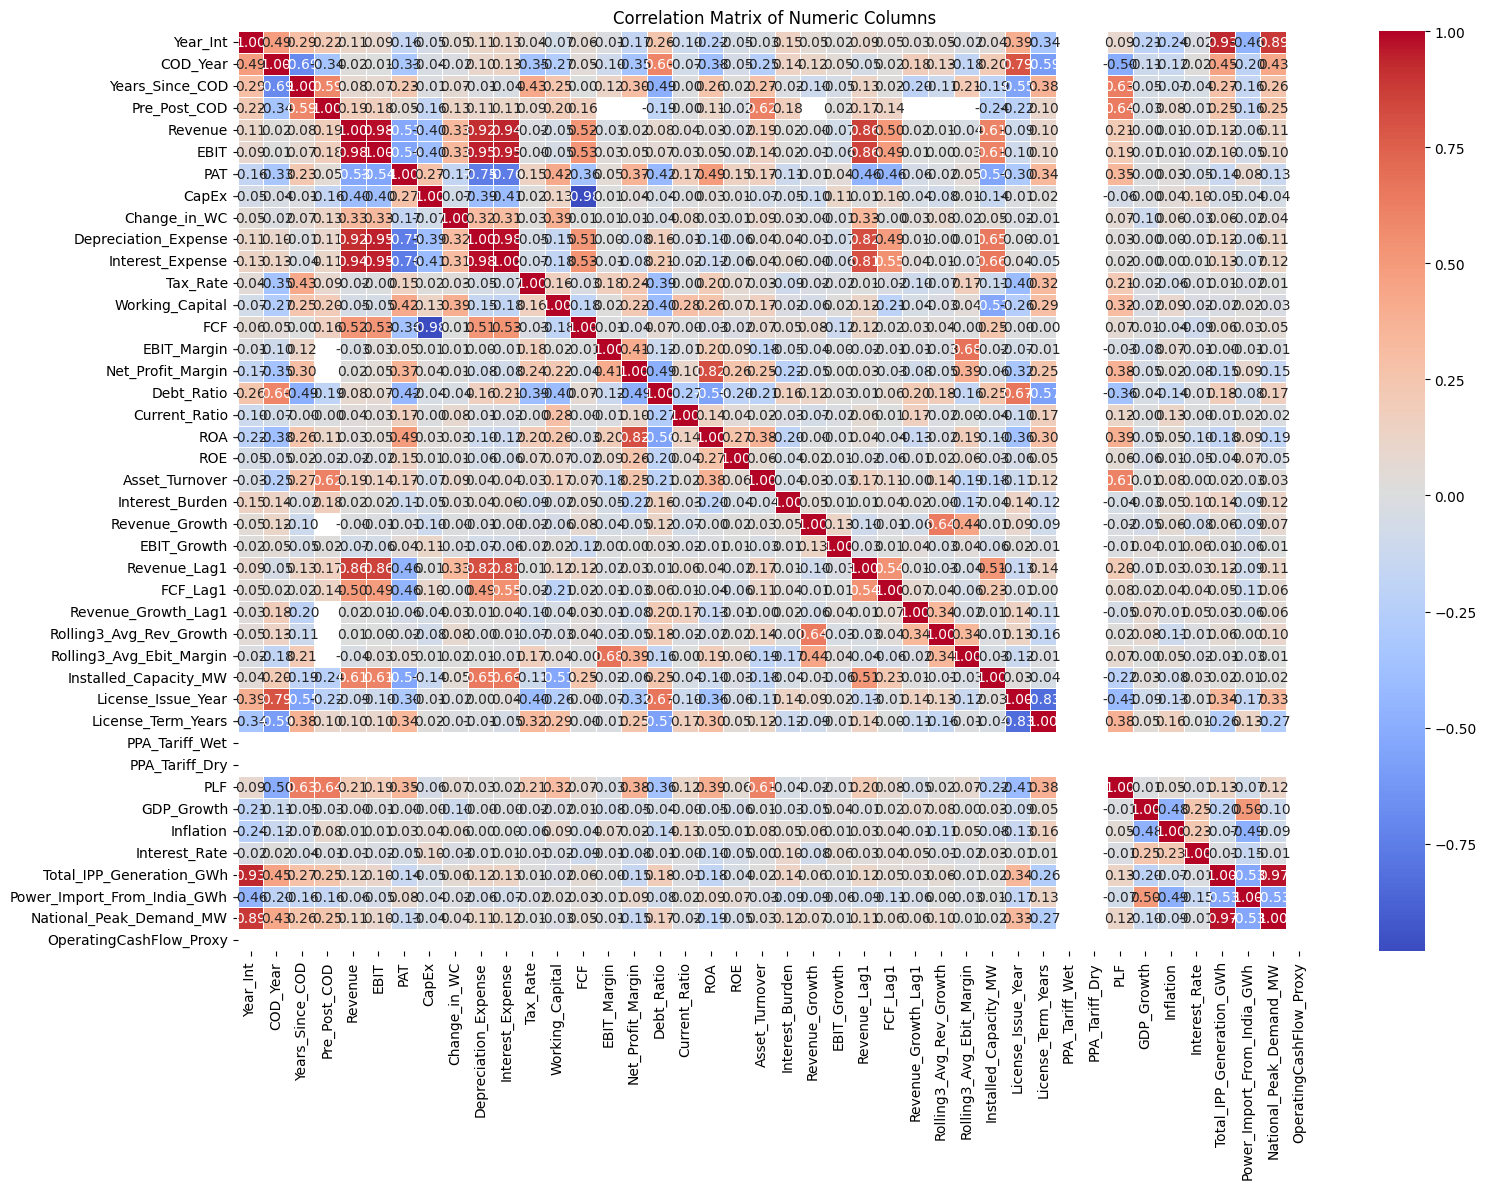

In [ ]:
numeric_df = df.select_dtypes(include=['number']) # Select only numeric columns
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Columns')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

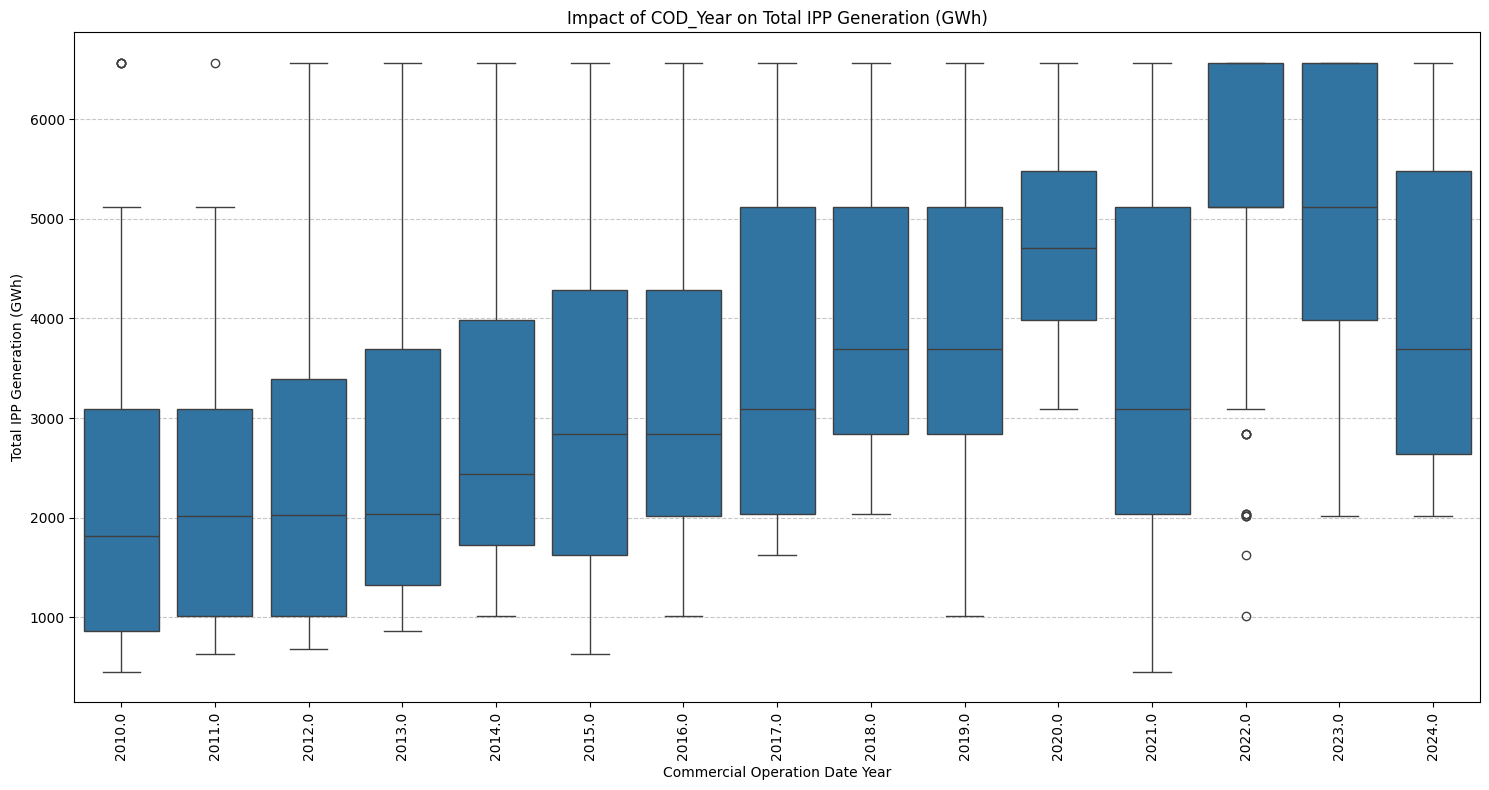

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='COD_Year', y='Total_IPP_Generation_GWh', data=df)
plt.title('Impact of COD_Year on Total IPP Generation (GWh)')
plt.xlabel('Commercial Operation Date Year')
plt.ylabel('Total IPP Generation (GWh)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
mean_generation_by_ticker = df.groupby('Ticker')['Total_IPP_Generation_GWh'].mean().reset_index()
print('Mean Total IPP Generation (GWh) by Ticker:')
display(mean_generation_by_ticker)

Mean Total IPP Generation (GWh) by Ticker:


,Ticker,Total_IPP_Generation_GWh
0,AHL,2302.403571
1,AHPC,2302.403571
2,AKJCL,3707.000000
3,AKPL,2960.530000
4,API,2444.596923
...,...,...
85,UPCL,3446.500000
86,UPPER,3446.500000
87,USHEC,4765.250000
88,USHL,5841.000000


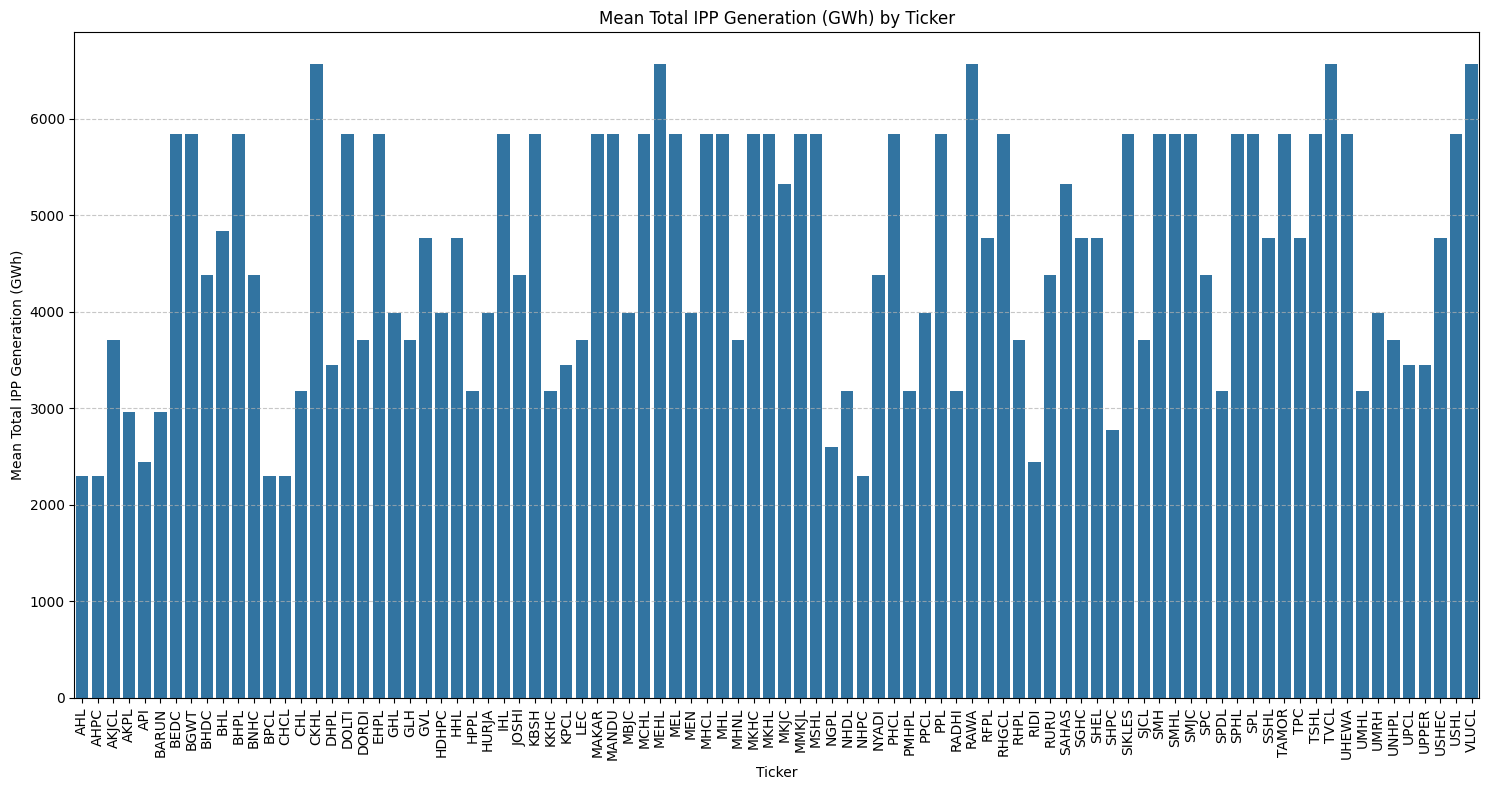

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.barplot(x='Ticker', y='Total_IPP_Generation_GWh', data=mean_generation_by_ticker)
plt.title('Mean Total IPP Generation (GWh) by Ticker')
plt.xlabel('Ticker')
plt.ylabel('Mean Total IPP Generation (GWh)')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
top_5_tickers = mean_generation_by_ticker.sort_values(by='Total_IPP_Generation_GWh', ascending=False).head(5)
display(top_5_tickers)

,Ticker,Total_IPP_Generation_GWh
15,CKHL,6564.0
37,MEHL,6564.0
89,VLUCL,6564.0
80,TVCL,6564.0
57,RAWA,6564.0


In [ ]:
correlations_with_generation = correlation_matrix['Total_IPP_Generation_GWh'].sort_values(ascending=False)
strongest_positive_correlations = correlations_with_generation[correlations_with_generation > 0].drop('Total_IPP_Generation_GWh', errors='ignore')

print("Columns with strongest positive correlation to 'Total_IPP_Generation_GWh':")
display(strongest_positive_correlations)

Columns with strongest positive correlation to 'Total_IPP_Generation_GWh':


,Total_IPP_Generation_GWh
National_Peak_Demand_MW,0.970357
Year_Int,0.934307
COD_Year,0.454113
License_Issue_Year,0.343690
Years_Since_COD,0.272348
Pre_Post_COD,0.253827
Debt_Ratio,0.180062
Interest_Burden,0.139731
PLF,0.126122
Interest_Expense,0.125488


#**FCF analysis**

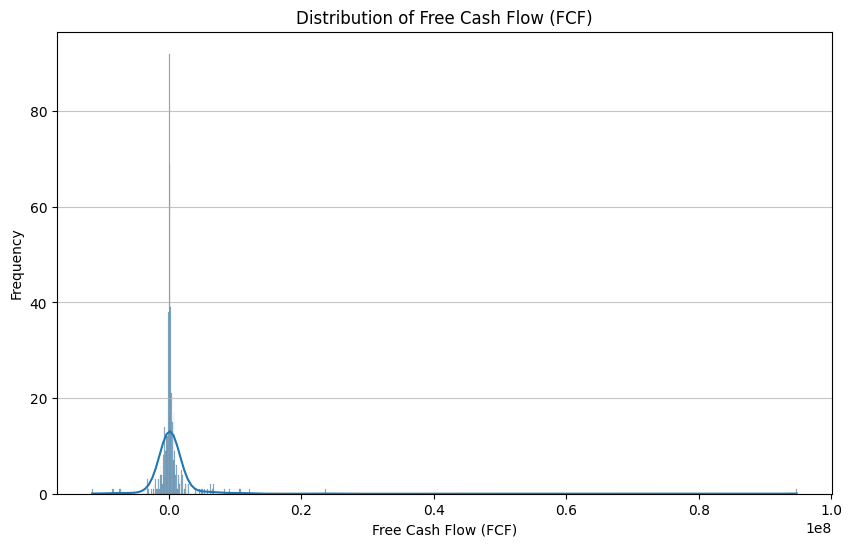

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['FCF'].dropna(), kde=True)
plt.title('Distribution of Free Cash Flow (FCF)')
plt.xlabel('Free Cash Flow (FCF)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
print(f"Missing values in 'FCF' column: {df['FCF'].isnull().sum()}")

Missing values in 'FCF' column: 0


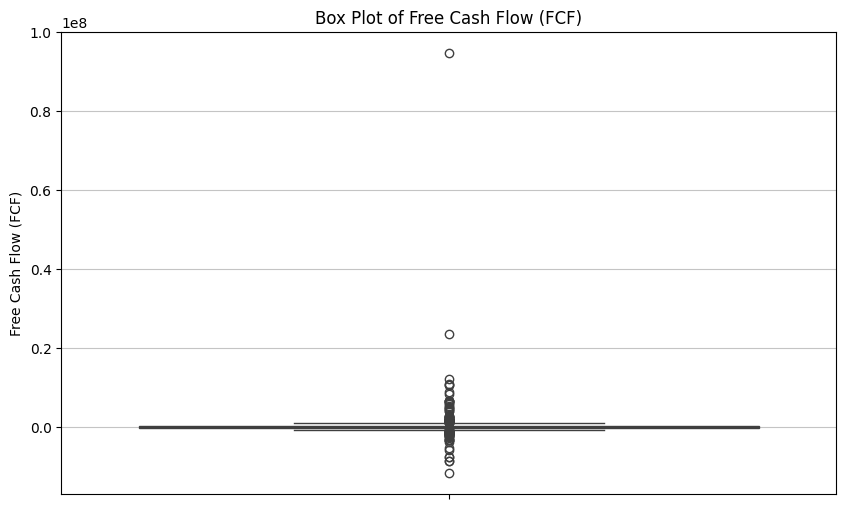

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['FCF'])
plt.title('Box Plot of Free Cash Flow (FCF)')
plt.ylabel('Free Cash Flow (FCF)')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
fcf_generation_correlation = df['FCF'].corr(df['Total_IPP_Generation_GWh'])
print(f"Correlation between 'FCF' and 'Total_IPP_Generation_GWh': {fcf_generation_correlation:.2f}")

Correlation between 'FCF' and 'Total_IPP_Generation_GWh': 0.06


In [ ]:
print("Correlations of 'FCF' with other financial columns:")
fcf_correlations = df.corr(numeric_only=True)['FCF'].sort_values(ascending=False)
display(fcf_correlations)

Correlations of 'FCF' with other financial columns:


,FCF
FCF,1.000000
Interest_Expense,0.529427
EBIT,0.525333
Revenue,0.517536
Depreciation_Expense,0.513606
Installed_Capacity_MW,0.254310
Pre_Post_COD,0.164470
Revenue_Lag1,0.122503
Revenue_Growth,0.077904
Asset_Turnover,0.070978


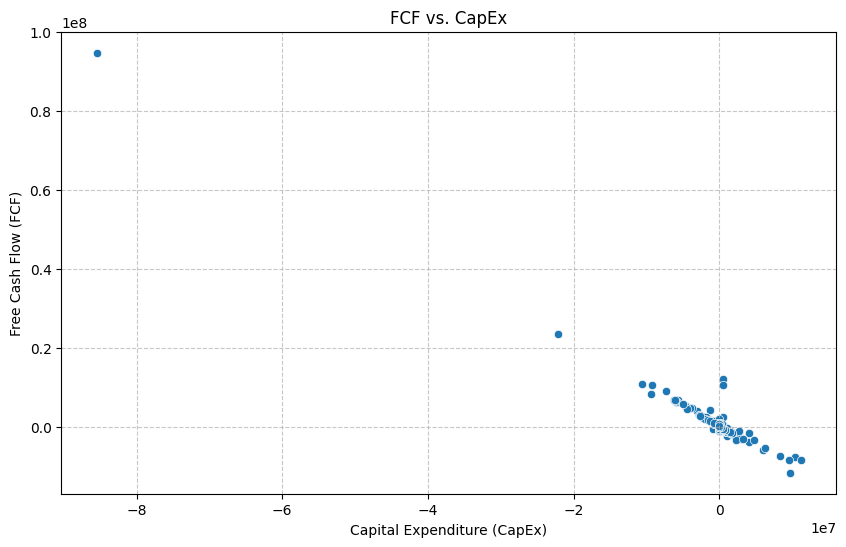

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CapEx', y='FCF', data=df)
plt.title('FCF vs. CapEx')
plt.xlabel('Capital Expenditure (CapEx)')
plt.ylabel('Free Cash Flow (FCF)')

# Dynamically set x and y limits for better visualization
x_min, x_max = df['CapEx'].min(), df['CapEx'].max()
y_min, y_max = df['FCF'].min(), df['FCF'].max()

# Add a small padding to the limits
x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05

plt.xlim(x_min - x_padding, x_max + x_padding)
plt.ylim(y_min - y_padding, y_max + y_padding)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Even with dynamic axis limits, the scatter plot is hard to interpret due to the presence of extreme outliers in both 'FCF' and 'CapEx'. Let's identify and filter out these outliers to get a clearer view of the main data distribution.

In [ ]:
import numpy as np

# Calculate IQR for FCF
Q1_fcf = df['FCF'].quantile(0.25)
Q3_fcf = df['FCF'].quantile(0.75)
IQR_fcf = Q3_fcf - Q1_fcf

# Calculate IQR for CapEx
Q1_capex = df['CapEx'].quantile(0.25)
Q3_capex = df['CapEx'].quantile(0.75)
IQR_capex = Q3_capex - Q1_capex

# Define bounds for FCF outliers (using 3*IQR for a more aggressive filter on extreme outliers)
lower_bound_fcf = Q1_fcf - 3 * IQR_fcf
upper_bound_fcf = Q3_fcf + 3 * IQR_fcf

# Define bounds for CapEx outliers (using 3*IQR for a more aggressive filter on extreme outliers)
lower_bound_capex = Q1_capex - 3 * IQR_capex
upper_bound_capex = Q3_capex + 3 * IQR_capex

# Filter out extreme outliers
df_filtered = df[(df['FCF'] >= lower_bound_fcf) & (df['FCF'] <= upper_bound_fcf) &
                 (df['CapEx'] >= lower_bound_capex) & (df['CapEx'] <= upper_bound_capex)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (after removing extreme outliers): {df_filtered.shape}")

Original DataFrame shape: (477, 44)
Filtered DataFrame shape (after removing extreme outliers): (325, 44)


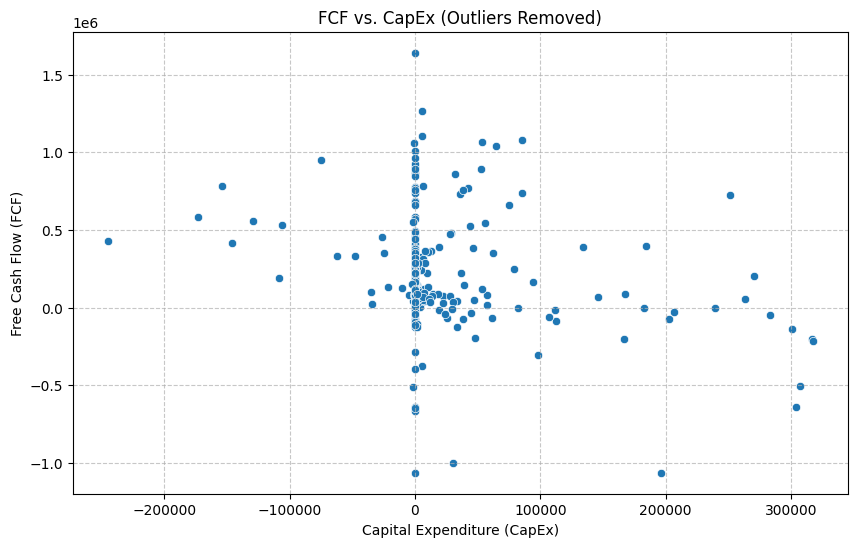

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CapEx', y='FCF', data=df_filtered)
plt.title('FCF vs. CapEx (Outliers Removed)')
plt.xlabel('Capital Expenditure (CapEx)')
plt.ylabel('Free Cash Flow (FCF)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# Perform linear regression
# Using 'Q("FCF")' and 'Q("CapEx")' to handle column names with special characters if any, though not strictly necessary here.
model = smf.ols('FCF ~ CapEx', data=df_filtered).fit()

# Print the regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    FCF   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     17.78
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           3.22e-05
Time:                        04:00:04   Log-Likelihood:                -4577.0
No. Observations:                 325   AIC:                             9158.
Df Residuals:                     323   BIC:                             9166.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.192e+05   1.82e+04     12.033      0.0

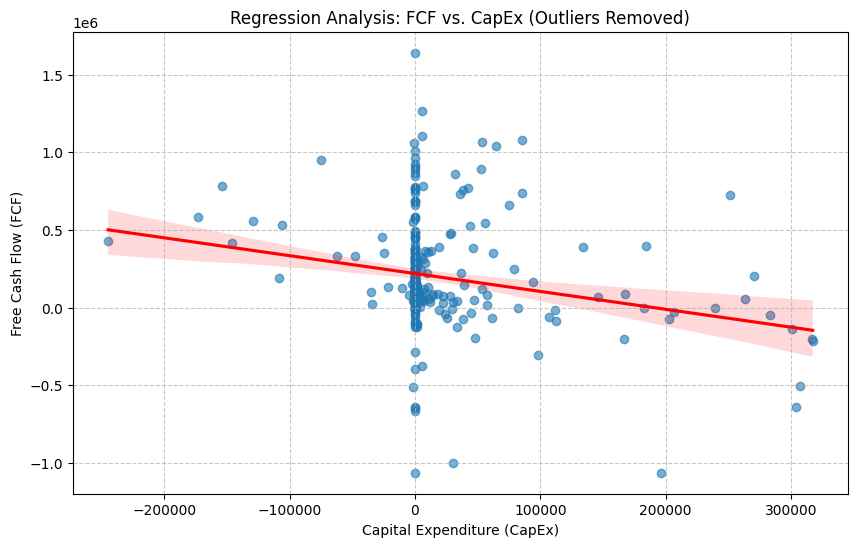

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='CapEx', y='FCF', data=df_filtered, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Regression Analysis: FCF vs. CapEx (Outliers Removed)')
plt.xlabel('Capital Expenditure (CapEx)')
plt.ylabel('Free Cash Flow (FCF)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Let's compare the FCF performance across different Tickers using boxplots. This will help us understand the distribution and spread of FCF for each company.

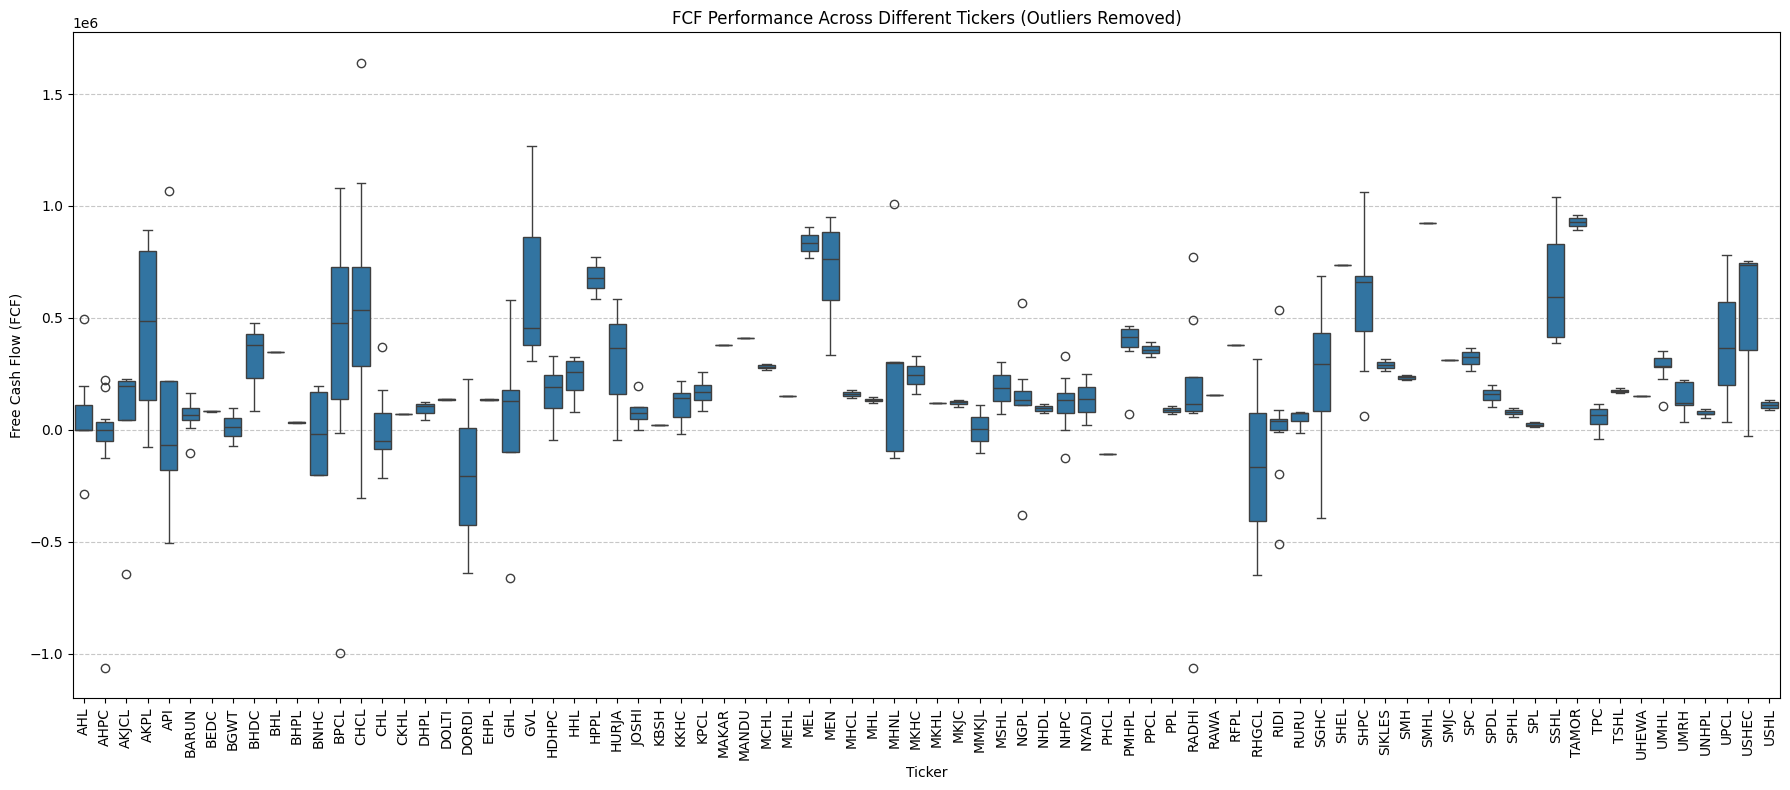

In [ ]:
plt.figure(figsize=(18, 8)) # Increase figure size for better readability with many tickers
sns.boxplot(x='Ticker', y='FCF', data=df_filtered)
plt.title('FCF Performance Across Different Tickers (Outliers Removed)')
plt.xlabel('Ticker')
plt.ylabel('Free Cash Flow (FCF)')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()